
# Food Delivery Time Prediction Project

## Project Goals
- Perform EDA (Exploratory Data Analysis)
- Clean the dataset
- Create Machine Learning models
- Evaluate model performance

Dataset: India Food Delivery Time Prediction


In [1]:
# Basic libraries for data handling, graphs and saving models.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from math import radians, sin, cos, sqrt, atan2
warnings.filterwarnings('ignore')


In [2]:
# Machine learning tools used in this project.
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


In [3]:
# Read the JSON dataset into a pandas dataframe.
df = pd.read_json('India-Food-Delivery-Time-Prediction.json')

# Show first five records to understand the data.
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30


In [4]:
# Shape tells total rows and columns in the dataset.
print("Shape of dataset:", df.shape)

# info() shows column names, data types and missing values.
df.info()


Shape of dataset: (41953, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null 

In [5]:
# Count missing values in every column.
df.isnull().sum()


ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [6]:
# Remove extra spaces from all text columns.
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()


In [7]:
# Convert wrong text missing values into real NaN values.
df.replace('NaN', np.nan, inplace=True)
df.replace('NaN ', np.nan, inplace=True)
df.replace('nan', np.nan, inplace=True)

# Clean weather names by removing repeated word.
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)


In [8]:
# Remove '(min)' text from delivery time column.
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min)', '', regex=False)

# Convert delivery time into number format for prediction.
df['Time_taken(min)'] = df['Time_taken(min)'].astype(float)


In [9]:
# These columns should be numeric, so convert them safely.
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing numeric values with median values.
df.fillna(df.median(numeric_only=True), inplace=True)


In [10]:
# Fill missing text values with the most common value.
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check cleaned data.
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0


In [11]:
# Create a function to calculate distance between two latitude-longitude points.
def haversine(lat1, lon1, lat2, lon2):
    # Store the radius of earth in kilometers.
    R = 6371
    # Convert all latitude and longitude values from degrees to radians.
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    # Find the difference between delivery latitude and restaurant latitude.
    dlat = lat2 - lat1
    # Find the difference between delivery longitude and restaurant longitude.
    dlon = lon2 - lon1
    # Apply the first part of the Haversine formula.
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    # Apply the second part of the Haversine formula.
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    # Multiply earth radius with formula result to get distance in kilometers.
    return R * c


In [12]:
# Create a new column named distance_km in the dataframe.
df['distance_km'] = df.apply(
    # For each row, call the haversine function.
    lambda row: haversine(
        # First value is restaurant latitude.
        row['Restaurant_latitude'],
        # Second value is restaurant longitude.
        row['Restaurant_longitude'],
        # Third value is delivery location latitude.
        row['Delivery_location_latitude'],
        # Fourth value is delivery location longitude.
        row['Delivery_location_longitude']
    ),
    # axis=1 means apply the function row by row.
    axis=1
)

# Display first five calculated distance values.
df[['distance_km']].head()


,distance_km
0,3.025149
1,20.183530
2,1.552758
3,7.790401
4,6.210138


# Exploratory Data Analysis (EDA)


In EDA, we use graphs to understand the dataset before building models.


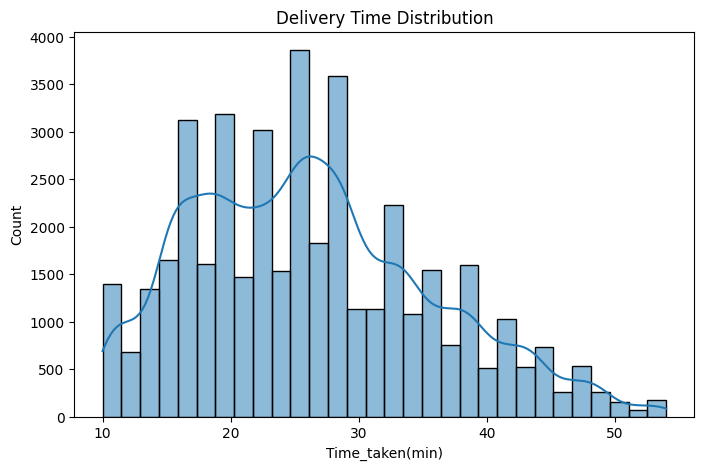

In [13]:
# Histogram shows how delivery time values are distributed.
plt.figure(figsize=(8,5))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True)
plt.title('Delivery Time Distribution')
plt.show()


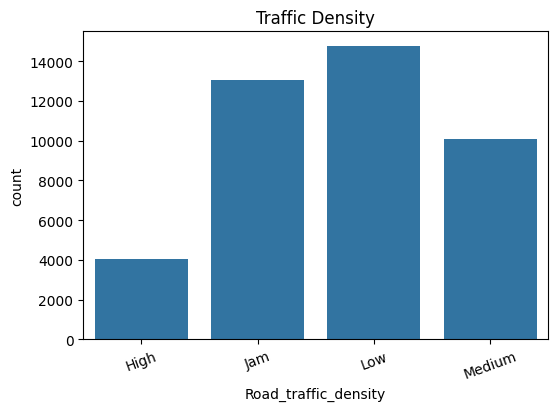

In [14]:
# Countplot shows number of orders in each traffic category.
plt.figure(figsize=(6,4))
sns.countplot(x='Road_traffic_density', data=df)
plt.title('Traffic Density')
plt.xticks(rotation=20)
plt.show()


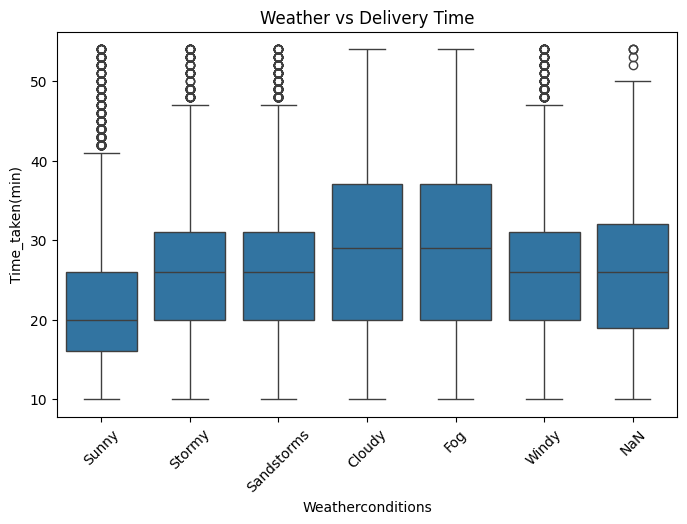

In [15]:
# Boxplot compares delivery time under different weather conditions.
plt.figure(figsize=(8,5))
sns.boxplot(x='Weatherconditions', y='Time_taken(min)', data=df)
plt.xticks(rotation=45)
plt.title('Weather vs Delivery Time')
plt.show()


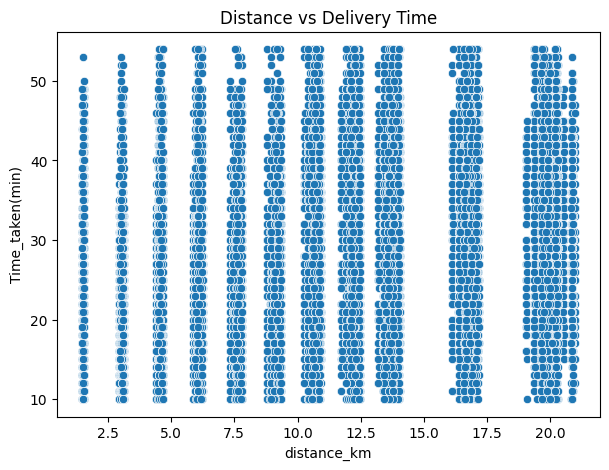

In [16]:
# Scatterplot checks relation between distance and delivery time.
plt.figure(figsize=(7,5))
sns.scatterplot(x='distance_km', y='Time_taken(min)', data=df)
plt.title('Distance vs Delivery Time')
plt.show()


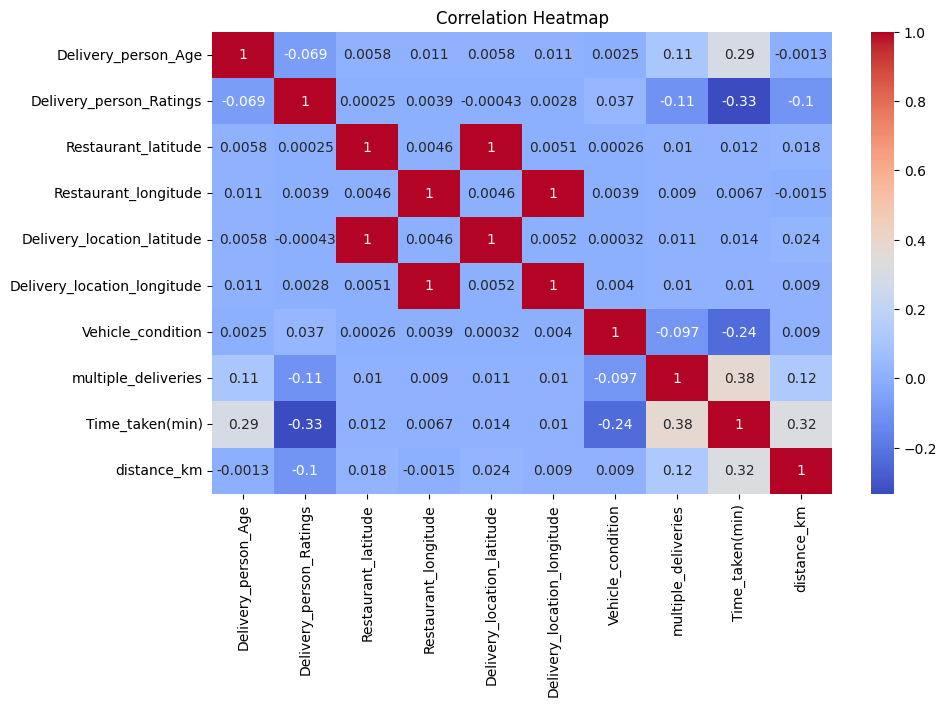

In [17]:
# Correlation shows relation between numeric columns.
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Feature Encoding


Machine learning models need numbers, so text columns are converted using dummy encoding.


In [18]:
# Use only meaningful columns for delivery time prediction.
selected_features = [
    'Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km',
    'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition',
    'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries',
    'Festival', 'City'
]


In [19]:
# get_dummies converts text categories into numeric columns.
features_df = df[selected_features]
X = pd.get_dummies(features_df, drop_first=True)

# X contains final input features for model training.
X.head()


,Delivery_person_Age,Delivery_person_Ratings,distance_km,Vehicle_condition,multiple_deliveries,Weatherconditions_Fog,Weatherconditions_NaN,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,...,Road_traffic_density_Medium,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban
0,37.0,4.9,3.025149,2,0.0,False,False,False,False,True,...,False,False,False,True,False,True,False,False,False,True
1,34.0,4.5,20.183530,2,1.0,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,23.0,4.4,1.552758,0,1.0,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True
3,38.0,4.7,7.790401,0,1.0,False,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False
4,32.0,4.6,6.210138,1,1.0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False


# Model Building


The same train-test split is used for all delivery-time models so comparison is fair.


In [20]:
# Target column is the value we want to predict.
y = df['Time_taken(min)']
print("Number of final input columns:", X.shape[1])
y.head()


Number of final input columns: 23


0    24.0
1    33.0
2    26.0
3    21.0
4    30.0
Name: Time_taken(min), dtype: float64

In [21]:
# Split data: 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)


(33562, 23)
(8391, 23)


# Linear Regression Model


In [22]:
# Train Linear Regression model.
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict delivery time for test data.
lr_predictions = lr_model.predict(X_test)


In [23]:
# Evaluate Linear Regression using MAE, RMSE and R2 score.
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)
print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)


Linear Regression Results
MAE: 4.764151235830587
RMSE: 6.017660697706603
R2 Score: 0.5796903448439847


# Decision Tree Regressor


In [24]:
# Decision Tree learns simple if-else type rules from data.
dt_model = DecisionTreeRegressor(random_state=42, max_depth=12)
dt_model.fit(X_train, y_train)

# Predict delivery time using Decision Tree.
dt_predictions = dt_model.predict(X_test)


In [25]:
# Evaluate Decision Tree model performance.
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)
print("Decision Tree Results")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)


Decision Tree Results
MAE: 3.3495232923607
RMSE: 4.29643463010292
R2 Score: 0.7857452839826974


# Random Forest Regressor


In [26]:
# Random Forest uses many decision trees together.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict delivery time using Random Forest.
rf_predictions = rf_model.predict(X_test)


In [27]:
# Evaluate Random Forest model performance.
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)
print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)


Random Forest Results
MAE: 3.2164187820283634
RMSE: 4.0977449449245995
R2 Score: 0.80510359890036


In [28]:
# Compare all delivery time prediction models in one table.
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [lr_mae, dt_mae, rf_mae],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse],
    'R2 Score': [lr_r2, dt_r2, rf_r2]
})
results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.764151,6.017661,0.579690
1,Decision Tree,3.349523,4.296435,0.785745
2,Random Forest,3.216419,4.097745,0.805104


# Second Machine Learning Task

## Traffic Density Prediction


This is a classification task because the model predicts a category like Low, Medium, High or Jam.


In [29]:
# This function extracts only hour from time value.
def get_hour(time_value):
    time_value = pd.to_datetime(time_value, format='%H:%M:%S', errors='coerce')
    return time_value.hour


In [30]:
# Create time-based features because traffic depends on time.
df['order_hour'] = df['Time_Orderd'].apply(get_hour)
df['pickup_hour'] = df['Time_Order_picked'].apply(get_hour)

# Fill missing hour values using median hour.
df['order_hour'] = df['order_hour'].fillna(df['order_hour'].median())
df['pickup_hour'] = df['pickup_hour'].fillna(df['pickup_hour'].median())


In [31]:
# Select inputs for traffic density prediction.
traffic_features = [
    'Weatherconditions', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
    'Festival', 'City', 'distance_km', 'Delivery_person_Age',
    'Delivery_person_Ratings', 'multiple_deliveries', 'order_hour', 'pickup_hour'
]


In [32]:
# Prepare X and y for the traffic classification task.
traffic_X = df[traffic_features]
traffic_X = pd.get_dummies(traffic_X, drop_first=True)
traffic_y = df['Road_traffic_density']
traffic_X.head()


,Vehicle_condition,distance_km,Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries,order_hour,pickup_hour,Weatherconditions_Fog,Weatherconditions_NaN,Weatherconditions_Sandstorms,...,Weatherconditions_Windy,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban
0,2,3.025149,37.0,4.9,0.0,11.0,11,False,False,False,...,False,False,False,True,False,True,False,False,False,True
1,2,20.183530,34.0,4.5,1.0,19.0,19,False,False,False,...,False,False,False,True,False,False,True,False,False,False
2,0,1.552758,23.0,4.4,1.0,8.0,8,False,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,7.790401,38.0,4.7,1.0,18.0,18,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1,6.210138,32.0,4.6,1.0,13.0,13,False,False,False,...,False,False,False,True,False,False,True,False,False,False


In [33]:
# Train Random Forest Classifier for traffic prediction.
traffic_X_train, traffic_X_test, traffic_y_train, traffic_y_test = train_test_split(
    traffic_X, traffic_y, test_size=0.2, random_state=42, stratify=traffic_y
)
traffic_model = RandomForestClassifier(n_estimators=200, random_state=42)
traffic_model.fit(traffic_X_train, traffic_y_train)
traffic_predictions = traffic_model.predict(traffic_X_test)


In [34]:
# Accuracy tells how many traffic labels were predicted correctly.
traffic_accuracy = accuracy_score(traffic_y_test, traffic_predictions)
print("Traffic Density Prediction Results")
print("Accuracy:", traffic_accuracy)
print(classification_report(traffic_y_test, traffic_predictions))


Traffic Density Prediction Results
Accuracy: 0.9724705041115481
              precision    recall  f1-score   support

        High       0.96      0.97      0.96       814
         Jam       0.96      0.97      0.97      2609
         Low       0.98      0.99      0.98      2951
      Medium       0.99      0.95      0.97      2017

    accuracy                           0.97      8391
   macro avg       0.97      0.97      0.97      8391
weighted avg       0.97      0.97      0.97      8391



# Save Models


Saving models allows us to use them later without training again.


In [35]:
# Save best delivery time model with its training columns.
delivery_model_data = {
    'model': rf_model,
    'columns': list(X.columns)
}
joblib.dump(delivery_model_data, 'best_delivery_time_model.joblib')
print("Best model saved as best_delivery_time_model.joblib")


Best model saved as best_delivery_time_model.joblib


In [36]:
# Save traffic density model with its training columns.
traffic_model_data = {
    'model': traffic_model,
    'columns': list(traffic_X.columns)
}
joblib.dump(traffic_model_data, 'traffic_density_model.joblib')
print("Traffic density model saved as traffic_density_model.joblib")


Traffic density model saved as traffic_density_model.joblib


# Final Conclusion

- Linear Regression improved after using dummy encoding instead of simple label numbers.
- Decision Tree and Random Forest gave better R2 scores for delivery time prediction.
- Random Forest is the best model for predicting delivery time in this project.
- Traffic density prediction improved after adding order hour and pickup hour.
- Both final models were saved as joblib files.
- Important factors are distance, traffic density, weather, time, ratings, festival and city type.
